# Tutorial de filtros FIR e IIR con SciPy
Este notebook muestra cómo diseñar y visualizar filtros **FIR** e **IIR** de tipo paso alto, paso banda y rechazo de banda utilizando la biblioteca `scipy.signal`.
Generado automáticamente con ChatGPT.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, butter, cheby1, ellip, freqz, sosfiltfilt, iirfilter

# Configuración de estilo
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.linestyle'] = '--'

In [ ]:
fs = 1000           # Frecuencia de muestreo
nyq = fs / 2        # Frecuencia de Nyquist
N = 101             # Número de coeficientes FIR (orden + 1)
order_iir = 4       # Orden IIR


## Filtros FIR con `firwin`

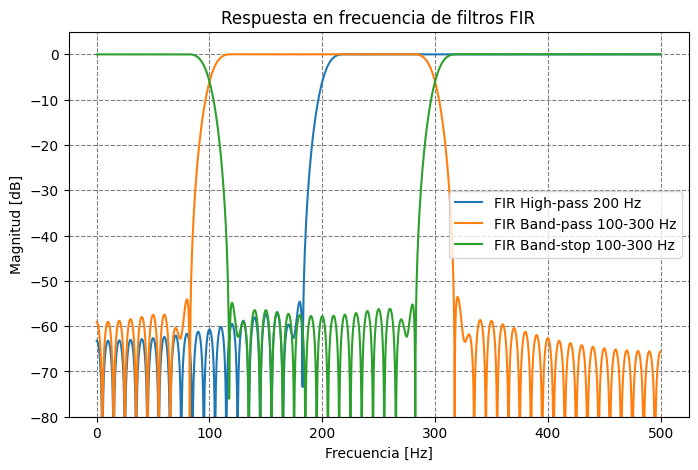

In [ ]:
# Diseño FIR
b_hp    = firwin(N, 200/nyq, pass_zero='highpass', window='hamming')
b_bp    = firwin(N, [100/nyq, 300/nyq], pass_zero='bandpass', window='hamming')
b_bs    = firwin(N, [100/nyq, 300/nyq], pass_zero='bandstop', window='hamming')

# Visualización de la respuesta en frecuencia
w_fir, h_fir_hp = freqz(b_hp, worN=2048, fs=fs)
_,    h_fir_bp = freqz(b_bp, worN=2048, fs=fs)
_,    h_fir_bs = freqz(b_bs, worN=2048, fs=fs)

plt.plot(w_fir, 20*np.log10(abs(h_fir_hp)), label='FIR High-pass 200 Hz')
plt.plot(w_fir, 20*np.log10(abs(h_fir_bp)), label='FIR Band-pass 100-300 Hz')
plt.plot(w_fir, 20*np.log10(abs(h_fir_bs)), label='FIR Band-stop 100-300 Hz')
plt.title('Respuesta en frecuencia de filtros FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.ylim(-80, 5)
plt.legend()
plt.grid(True)
plt.show()

## Filtros IIR con `butter`, `cheby1` y `ellip`

In [ ]:
# Diseño IIR (ba) y SOS
b_hp_iir, a_hp_iir = butter(order_iir, 200/nyq, btype='highpass', output='ba')
b_bp_iir, a_bp_iir = cheby1(order_iir, 1, [100/nyq, 300/nyq], btype='bandpass', output='ba')
sos_bs_iir        = iirfilter(order_iir, [100/nyq, 300/nyq], btype='bandstop', ftype='butter', output='sos')

# Visualización de la respuesta en frecuencia IIR
w_iir, h_hp_iir = freqz(b_hp_iir, a_hp_iir, worN=2048, fs=fs)
_,    h_bp_iir = freqz(b_bp_iir, a_bp_iir, worN=2048, fs=fs)
w_sos, h_bs_iir = freqz(sos_bs_iir, worN=2048, fs=fs)

plt.plot(w_iir, 20*np.log10(abs(h_hp_iir)), label='IIR High-pass Butter 200 Hz')
plt.plot(w_iir, 20*np.log10(abs(h_bp_iir)), label='IIR Band-pass Cheby1 100-300 Hz')
plt.plot(w_sos, 20*np.log10(abs(h_bs_iir)), label='IIR Band-stop Butter (SOS) 100-300 Hz')
plt.title('Respuesta en frecuencia de filtros IIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.ylim(-80, 5)
plt.legend()
plt.grid(True)
plt.show()

ValueError: operands could not be broadcast together with shapes (6,) (2048,) 